# Cyclistic Bike-Share Data Analysis

## Business Task

Cyclistic's marketing team wants to understand how annual members and casual riders use the bike-share service differently. The goal of this analysis is to identify behavioral differences between the two groups and provide data-driven recommendations to help convert casual riders into annual members.

## Tools Used

- Python
- Pandas
- Matplotlib
- SQL (later in the project)
- Tableau (later in the project)

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    r"C:/Users/traor/Documents/Case_Study/Cyclistic_Capstone/data/cleaned/cyclistic_cleaned.csv",
    parse_dates=["started_at", "ended_at"]
)

print(df.shape)

(5932285, 19)


In [51]:
membership_counts = (
    df["member_casual"]
    .value_counts()
)

print(membership_counts)

member_casual
member    3815672
casual    2116613
Name: count, dtype: int64


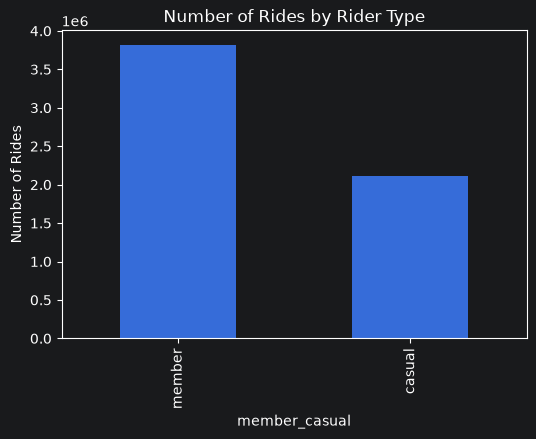

In [52]:
membership_counts.plot(
    kind="bar",
    figsize=(6,4),
    title="Number of Rides by Rider Type"
)

plt.ylabel("Number of Rides")
plt.show()

## Finding 1: Number of Rides by Rider Type

### Observation
Annual members completed substantially more rides than casual riders during the study period.

### Business Interpretation
This suggests that annual members rely on Cyclistic for regular transportation, while casual riders use the service less frequently.

### Recommendation
Cyclistic should target frequent casual riders with membership promotions highlighting the long-term value and convenience of annual memberships.

In [53]:
ride_length = (
    df.groupby("member_casual")["ride_length"]
      .mean()
      .round(2)
)

print(ride_length)

member_casual
casual    21.73
member    12.46
Name: ride_length, dtype: float64


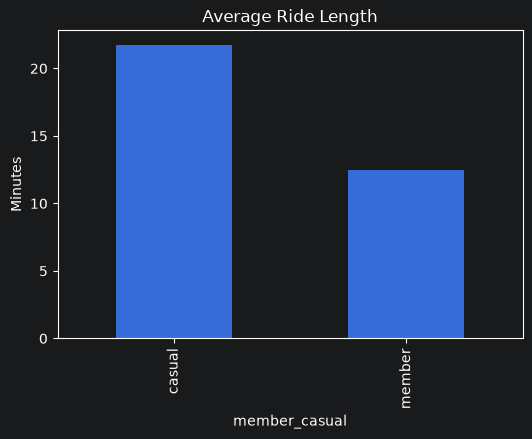

In [54]:
ride_length.plot(
    kind="bar",
    figsize=(6,4),
    title="Average Ride Length"
)

plt.ylabel("Minutes")
plt.show()

## Finding 2: Average Ride Length

### Observation
Casual riders have a noticeably longer average ride length than annual members.

### Business Interpretation
This indicates that casual riders primarily use Cyclistic for leisure and recreational activities, while members tend to use bikes for shorter, practical trips such as commuting.

### Recommendation
Cyclistic could create marketing campaigns emphasizing how annual memberships are useful not only for commuting but also for recreational riding.

In [44]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday = (
    df.groupby(
        ["day_of_week","member_casual"]
    )
    .size()
    .unstack()
)

weekday = weekday.reindex(weekday_order)

print(weekday)

member_casual  casual  member
day_of_week                  
Monday         245795  535670
Tuesday        244923  618815
Wednesday      235481  602616
Thursday       264543  609083
Friday         331433  559952
Saturday       446405  483593
Sunday         348033  405943


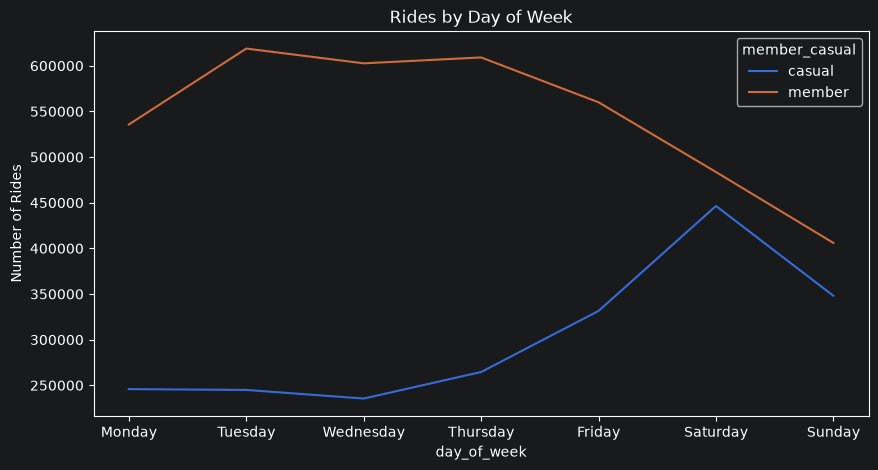

In [45]:
weekday.plot(
    figsize=(10,5)
)

plt.title("Rides by Day of Week")
plt.ylabel("Number of Rides")
plt.show()

## Finding 3: Weekly Riding Patterns

### Observation
Member rides remain relatively consistent throughout the workweek, while casual riders peak on weekends.

### Business Interpretation
The pattern suggests that members primarily commute during weekdays, whereas casual riders are more likely to ride for leisure during weekends.

### Recommendation
Weekend marketing campaigns and seasonal promotions may be effective in converting casual riders into annual members.

In [46]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly = (
    df.groupby(
        ["month","member_casual"]
    )
    .size()
    .unstack()
)

monthly = monthly.reindex(month_order)

print(monthly)

member_casual  casual  member
month                        
January         24740  113042
February        41173  160281
March           87850  229165
April          131514  316738
May            245143  408604
June           308485  454089
July           323352  440106
August         337878  452439
September      265268  449294
October        224038  422058
November        99082  257401
December        28090  112455


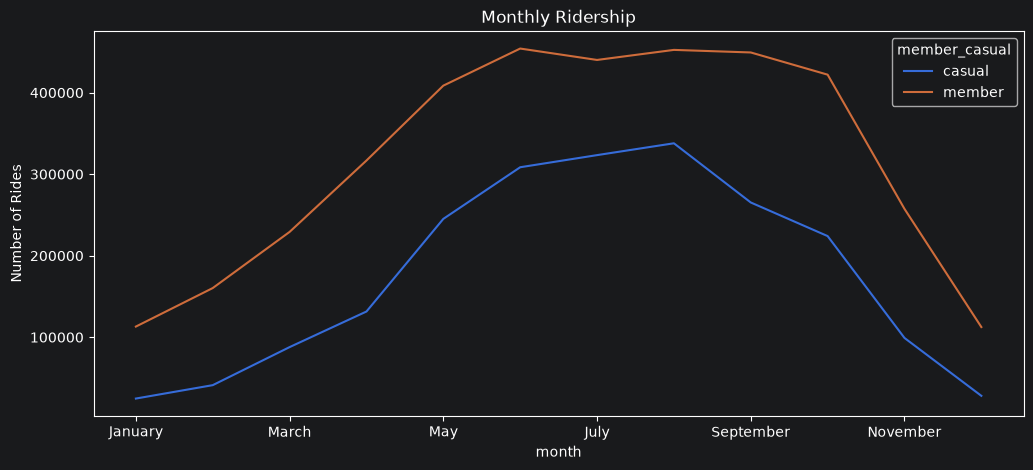

In [47]:
monthly.plot(
    figsize=(12,5)
)

plt.title("Monthly Ridership")
plt.ylabel("Number of Rides")
plt.show()

## Finding 4: Seasonal Trends

### Observation
Ridership for both groups increases during spring and summer and decreases during winter.

### Business Interpretation
Bike usage is seasonal, with warmer months driving significantly higher demand, especially among casual riders.

### Recommendation
Cyclistic should focus advertising and promotional efforts during late spring and summer when casual ridership is highest.

In [48]:
hourly = (
    df.groupby(
        ["hour","member_casual"]
    )
    .size()
    .unstack()
)

print(hourly)

member_casual  casual  member
hour                         
0               43249   35241
1               28242   21487
2               18350   12870
3               10246    8378
4                8246    9394
5               12898   37018
6               28367  108329
7               52119  215458
8               74852  278927
9               73241  176580
10              88308  150973
11             112921  176346
12             134170  201182
13             138968  197889
14             145653  200529
15             162014  254168
16             186392  360980
17             201545  411562
18             173190  319868
19             130024  221698
20              94167  154563
21              80356  120214
22              69271   87470
23              49824   54548


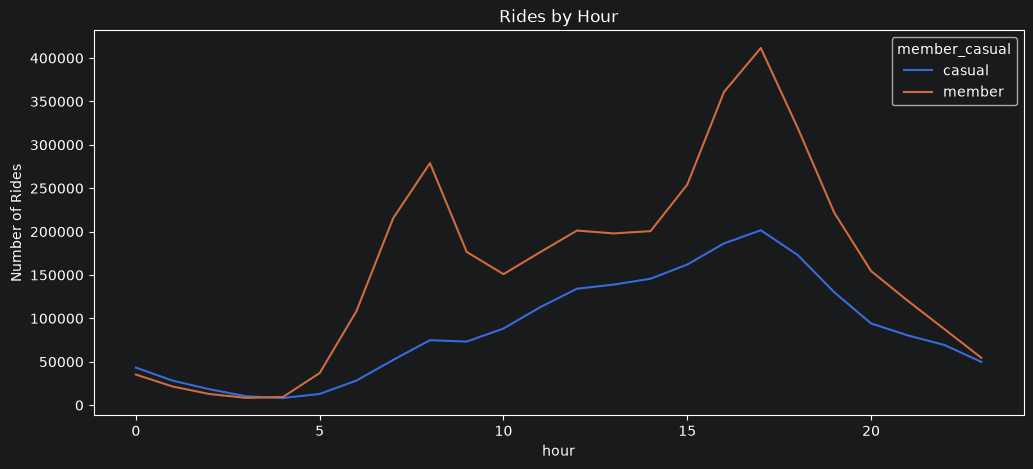

In [49]:
hourly.plot(
    figsize=(12,5)
)

plt.title("Rides by Hour")
plt.ylabel("Number of Rides")
plt.show()

## Finding 5: Hourly Riding Patterns

### Observation
Member rides show clear morning and evening peaks, while casual riders are most active during the afternoon.

### Business Interpretation
The commuting pattern of members differs significantly from the recreational riding behavior of casual riders.

### Recommendation
Cyclistic could design marketing campaigns encouraging casual riders to use annual memberships for everyday transportation, not just leisure activities.